In [22]:
import numpy as np
import phate, scprep
from scipy.stats import spearmanr
import seaborn as sns
import matplotlib.pyplot as plt

In [25]:
colors = {'mustard': '#E1AD01', 'berry': '#AC2F3D', 'teal': '#216E76', 'purple':'#502A4F', 'forest': '#065535', 'light forest': '#519167',
          'light yellow': '#E3BC81', 'light berry': '#c7505d', 'light teal': '#81ABA1', 'light purple': '#95636E', 'black': '#000000',
          'gray': '#808080'}

In [28]:
clist = ['gray', 'black', 'light yellow']

In [16]:
sns.set(font_scale=1.2, style='white')

In [30]:
dirac_embeddings = {}
dirac_embeddings['GSPA'] = np.load('results/GSPA_64.npy')
dirac_embeddings['GSPA_QR'] = np.load('results/GSPA_QR_64.npy')
dirac_embeddings['MAGIC'] = np.load('results/MAGIC_64.npy')

In [24]:
methods = ['GSPA', 'GSPA_QR', 'MAGIC']

In [7]:
index = np.array(list(range(0, 10000-0, 64)))
labels_y = (np.array(list(range(10000))) / 10000)[index]

In [8]:
phates = {}
ev_spearman = {}

In [31]:
for method in methods:
    phate_op = phate.PHATE(verbose=0)
    phates[method] = phate_op.fit_transform(dirac_embeddings[method])
    ev_spearman[method] = spearmanr(phate_op.graph.to_pygsp().U[:, 1], labels_y).correlation

2023-10-30 20:58:56,454:[WARNING](pygsp.graphs.graph._check_fourier_properties): The Fourier basis G.U is not available, we need to compute the Fourier basis. Explicitly call G.compute_fourier_basis() once beforehand to suppress the warning.
2023-10-30 20:58:56,600:[WARNING](pygsp.graphs.graph._check_fourier_properties): The Fourier basis G.U is not available, we need to compute the Fourier basis. Explicitly call G.compute_fourier_basis() once beforehand to suppress the warning.
2023-10-30 20:58:56,741:[WARNING](pygsp.graphs.graph._check_fourier_properties): The Fourier basis G.U is not available, we need to compute the Fourier basis. Explicitly call G.compute_fourier_basis() once beforehand to suppress the warning.


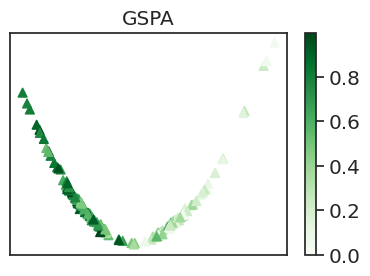

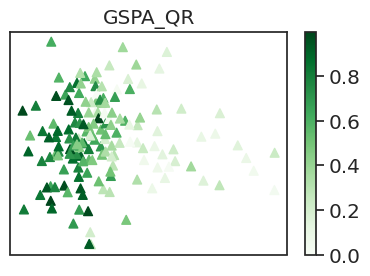

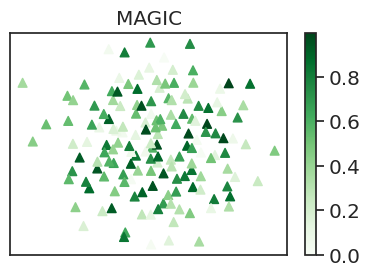

In [32]:
for method in methods:
    scprep.plot.scatter2d(phates[method], ticks=None, c=labels_y, cmap='Greens', title=method, figsize=(4,3), dpi=200,
                          filename=f'figures/{method}_dirac_embedding.png', marker='^', s=40)

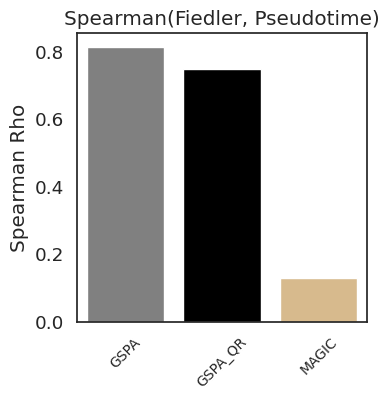

In [33]:
fig,ax = plt.subplots(figsize=(4,4))
sns.barplot(x=methods, y=[np.abs(ev_spearman[name]) for name in methods], palette=[colors[c] for c in clist], )
plt.xticks(rotation=45)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=10)
plt.ylabel('Spearman Rho')
plt.tight_layout()
plt.title('Spearman(Fiedler, Pseudotime)')
fig.savefig('figures/ev_corr.png', dpi=200)